In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import tifffile as tf
from glob import glob
import os
import tifffile as tf

from scipy import ndimage, interpolate, spatial

In [2]:
struc1 = ndimage.generate_binary_structure(2,1)
struc2 = ndimage.generate_binary_structure(2,2)

wsrc = '../cell_dams/'
nsrc = '../nuclear_mask/'
ksrc = '../kde/'
csrc = '../data/'
dst = '../proc/'

sample = 'B1'
sdst = dst + sample + '/'
if not os.path.isdir(sdst):
    os.mkdir(sdst)

In [3]:
wall = tf.imread(wsrc + sample + '_dams.tif').astype(bool)
edt = tf.imread(nsrc + sample + '_EDT.tif')
nuclei = edt < 2
wcoords = np.array(np.nonzero(~wall))

pad = 5
cy,cx = wall.shape
xaxis = np.arange(0, cx, pad)
yaxis = np.arange(0, cy, pad)

In [4]:
label, cellnum = ndimage.label(wall, struc1)
objss = ndimage.find_objects(label)
cnuclei = np.asarray(ndimage.center_of_mass(wall, label, range(1,cellnum+1)))
print('Detected',cellnum,'cells')

Detected 1662 cells


# Match cells

In [5]:
transcriptomes = sorted([os.path.splitext(foo)[0].split('_' + sample + '_')[-1] for foo in glob(ksrc + sample + '/meta*.csv')])
print(len(transcriptomes), 'transcriptomes')

filename = csrc + sample + '_data/32771-slide1_' + sample + '_results.txt'
data = pd.read_csv(filename, header=None, sep='\t').drop(columns=[4])
data.columns = ['X', 'Y', 'Z', 'T']

0 transcriptomes


In [7]:
filename = csrc + sample + '_data/' + transcriptomes[0] + '/' + transcriptomes[0] + ' - localization results by cell.csv'
print(filename)
df = pd.read_csv(filename)
print(df.shape)
df = df.iloc[~np.any(df.iloc[:, :5].isnull().values, axis=1)]
df = df[df['Cell.Area..px.'] > 9]
print(df.shape)

sel = [0,3,4,5,6,7,8,9]
df = df.astype(dict(zip(df.columns[np.array(sel)], [int for i in range(len(sel))])))

dcoords = np.round(df.iloc[:, 1:3].values).astype(int)

df.head()

../data/B1_data/CYP93A1/CYP93A1 - localization results by cell.csv
(1694, 24)
(1664, 24)


,Cell.ID..,X.location,Y.location,Bouding.box.X,Bouding.box.Y,Bouding.box.width,Bouding.box.height,Cell.Area..px.,Nucleus.Area..px.,Total.transcript..,...,Median.distance.from.nucleus.incl..nucleus..px.,Median.distance.from.nucleus.excl..nucleus..px.,X1st.quartile.distance.w..nucleus..px.,X1st.quartile.distance.w.o.nucleus..px.,X3rd.quartile.distance.w..nucleus..px.,X3rd.quartile.distance.w.o.nucleus..px.,nuclear.only.transcripts,average.nuclear.transcript.percentage,Total.cells.expressed,Nuc_cells_exp
1,1,7209.574,7213.375,0,0,10720,15008,63530175,182824,691,...,106.0,142.0,10.0,68.0,216.0,256.0,142.0,20.5,327,122
2,2,2495.503,1067.266,2344,905,271,324,53837,0,5,...,108.0,108.0,91.0,91.0,154.0,154.0,0.0,0.0,327,122
3,3,2524.642,1392.115,2064,961,961,849,390626,1246,32,...,143.0,153.0,64.0,72.0,202.0,202.0,1.0,3.1,327,122
4,4,3136.522,1323.289,2979,1131,286,386,69756,0,4,...,329.0,329.0,303.0,303.0,381.0,381.0,0.0,0.0,327,122
5,5,3405.303,1228.345,3328,1164,186,136,9433,0,4,...,311.0,311.0,307.0,307.0,312.0,312.0,0.0,0.0,327,122


In [8]:
cdist = spatial.distance.cdist(np.flip(cnuclei, axis=1), dcoords, metric='euclidean')
cmatches = np.argmin(cdist, axis=1)

In [9]:
tidx = 0

tcoords = data.loc[ data['T'] == transcriptomes[tidx] , ['X', 'Y', 'Z'] ].values.T
nmask = ~nuclei[ tcoords[1], tcoords[0] ]

coords = tcoords[:2, nmask]
tdst = sdst + transcriptomes[tidx] + '/'
if not os.path.isdir(tdst):
    os.mkdir(tdst)
print(tdst)

../proc/B1/CYP93A1/


# Load KDE

In [10]:
filename = ksrc + sample + '/kde_' + sample + '_' + transcriptomes[tidx] + '.npy'
isj = np.load(filename, allow_pickle=True)
filename = ksrc + sample + '/meta_' + sample + '_' + transcriptomes[tidx] + '.csv'
meta = pd.read_csv(filename, header=None, index_col=0)
#bw = meta.iloc[0, 1:3].values

# Individual cells

In [11]:
interp = interpolate.RegularGridInterpolator((yaxis, xaxis), isj, method='linear', bounds_error=True, fill_value=None)
bins = np.linspace(0, isj.max(), 256)

In [12]:
if False:

    tpercell = np.zeros((cellnum), dtype=int)
    for i in range(cellnum):
        lmask = label[ coords[1], coords[0] ] == i + 1
        tpercell[i] = np.sum(lmask)
    
    tpcargsort = np.argsort( tpercell )[::-1]
    for i in range(15):
        print(i, tpcargsort[i], tpercell[tpcargsort[i]], sep='\t')

In [15]:
cidx = 0
cdata = df.iloc[cmatches[cidx]]

ss = objss[cidx]
css = (np.s_[ss[0].start // pad : ss[0].stop // pad + 2], np.s_[ss[1].start // pad : ss[1].stop // pad + 2 ])
cxs = xaxis[css[1]]
cys = yaxis[css[0]]
cisj = isj[css]

ss = (np.s_[ cys[0]:cys[-1] ], np.s_[ cxs[0]:cxs[-1] ])
extent = (ss[1].start, ss[1].stop, ss[0].start, ss[0].stop)

cell = wall[ss].copy().astype(np.uint8)
cell[ label[ss] == cidx+1 ] += 1

ccoords = coords[:2, label[ coords[1], coords[0] ] == cidx + 1 ].copy()

wcellcoords = np.asarray(np.nonzero(~wall[ss]))
wcellcoords[0] += ss[0].start
wcellcoords[1] += ss[1].start
print(cell.shape, ccoords.shape, ss, sep='\t')

cellcoords = np.asarray(np.nonzero(label == cidx + 1))

(15005, 10715)	(2, 550)	(slice(0, 15005, None), slice(0, 10715, None))


In [18]:
cellcoords

array([[    0,     0,     0, ..., 15007, 15007, 15007],
       [    0,     1,     2, ..., 10717, 10718, 10719]])

In [16]:
cvals = interp(cellcoords.T)

cpdf = np.zeros(cell.shape)
cpdf[cellcoords[0]-ss[0].start, cellcoords[1] - ss[1].start] = cvals
dig = np.digitize(cpdf, bins, right=True).astype(np.uint8)

ValueError: One of the requested xi is out of bounds in dimension 0

../proc/B1/CYP93A1/diagnostic_CYP93A1_-_01621_-_01648.tif


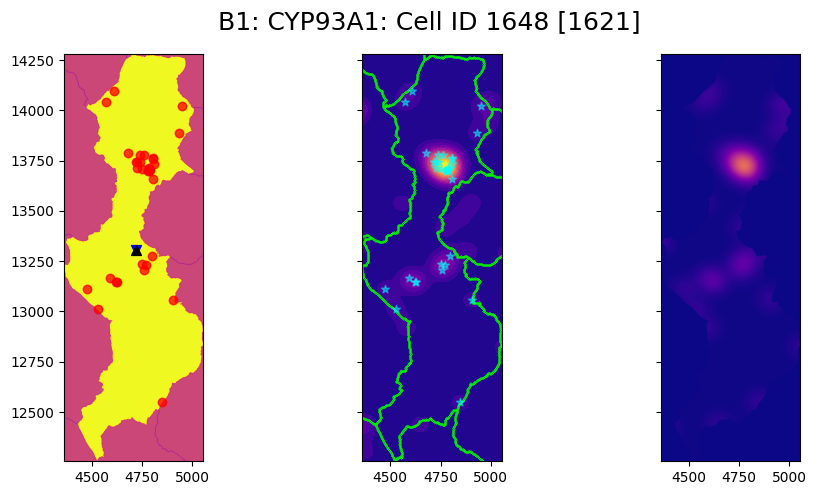

In [100]:
fig, ax = plt.subplots(1,3,figsize=(10,5), sharex=True, sharey=True)
ax = np.atleast_1d(ax).ravel()

ax[0].imshow(cell, cmap='plasma', origin='lower', extent=extent)
ax[0].scatter(*cdata[1:3].values, c='blue', marker='v', zorder=2, s=50)
ax[0].scatter(cnuclei[cidx,1], cnuclei[cidx,0], c='black', marker='^', zorder=2, s=50)
ax[0].scatter(ccoords[0], ccoords[1], c='red', marker='o', zorder=3, alpha=0.5);
ax[0].scatter(ccoords[0], ccoords[1], c='red', marker='o', zorder=3, alpha=0.5);

ax[1].contourf(cxs, cys, cisj, 16, cmap='plasma', vmin=0, zorder=1)
ax[1].scatter(wcellcoords[1], wcellcoords[0], c='lime', marker='.', s=0.1)
ax[1].scatter(ccoords[0], ccoords[1], c='cyan', marker='*', zorder=3, alpha=0.5);

ax[2].imshow(dig, origin='lower', cmap='plasma', extent=extent, vmax=255)

step = int(np.ediff1d(ax[0].get_xticks())[0])
for i in range(len(ax)):
    ax[i].set_aspect('equal')
    ax[i].margins(0)

title = '{}: {}: Cell ID {} [{}]'.format(sample, transcriptomes[tidx], int(cdata['Cell.ID..']), cidx)
fig.suptitle(title, fontsize=18)
fig.tight_layout();

filename = tdst + 'diagnostic_' + transcriptomes[tidx] + '_-_{:05d}_-_{:05d}.tif'.format(cidx, int(cdata['Cell.ID..']))
print(filename)

In [102]:
coords

array([[  702,  1355,  1559, ...,  4365,  4609,  5895],
       [ 1434,   977,  1226, ..., 14358, 14096, 13370]])

In [95]:
filename = tdst + transcriptomes[tidx] + '_-_{:05d}_-_{:05d}.tif'.format(cidx, int(cdata['Cell.ID..']))
print(filename)
#tf.imwrite(filename, dig, photometric='minisblack')

../proc/B1/CYP93A1/CYP93A1_-_01621_-_01648.tif
